# Simple OOD accuracy benchmark

This notebook is intentionally self-contained. It has three extension points:

1. One `prep_dataset_<name>()` function per dataset.
2. One entry per method in `METHOD_CONFIGS`.
3. `benchmark(dataset_names, method_names)`, which accepts two lists and returns raw results plus per-dataset and overall rankings.

The positive evaluation label is always **1 = OOD**. AUROC is the primary ranking metric; average precision and timing are recorded as secondary diagnostics.

The paper-derived tabular datasets are adapted to a held-out one-class OOD setting. This is appropriate for evaluating `fit(X_ID)` followed by `score_samples(X_test)`, but it is not an exact reproduction of the paper's original in-sample rare-point tables.

In [1]:
from __future__ import annotations

import copy
import sys
import time
import warnings
from dataclasses import dataclass, field
from functools import lru_cache
from pathlib import Path
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, load_digits, load_iris, load_wine
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.neighbors import LocalOutlierFactor

# Locate a source checkout when the notebook is run from the repository or its
# benchmarks/notebooks directory. Installed packages require no path changes.
for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
    if (candidate / "hirank" / "rankod.py").exists():
        sys.path.insert(0, str(candidate))
        break

try:
    from hirank import KNNOD
except ImportError as exc:
    raise ImportError(
        "This notebook expects the updated hirank package containing KNNOD. "
        "Install the package or run the notebook from its source checkout."
    ) from exc

SEED = 20260619
DATA_HOME = Path.home() / ".cache" / "hirank_ood_benchmarks"
DATA_HOME.mkdir(parents=True, exist_ok=True)


## Common data structure and preprocessing helpers

Every preparation function returns an `OODDataset`. Only `X_fit` is passed to `fit`; `X_test` contains both held-out ID points and OOD points.

In [2]:
@dataclass
class OODDataset:
    name: str
    X_fit: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray  # 0 = ID, 1 = OOD
    metadata: dict[str, Any] = field(default_factory=dict)

    def summary(self) -> dict[str, Any]:
        return {
            "dataset": self.name,
            "n_fit": int(self.X_fit.shape[0]),
            "n_test": int(self.X_test.shape[0]),
            "n_test_id": int(np.sum(self.y_test == 0)),
            "n_test_ood": int(np.sum(self.y_test == 1)),
            "n_features": int(self.X_fit.shape[1]),
            **self.metadata,
        }


def _fit_whitener(X: np.ndarray, eps: float = 1e-6):
    X = np.asarray(X, dtype=float)
    center = X.mean(axis=0)
    X0 = X - center
    covariance = np.atleast_2d(np.cov(X0, rowvar=False))
    values, vectors = np.linalg.eigh(
        covariance + eps * np.eye(covariance.shape[0])
    )
    values = np.maximum(values, eps)
    transform = vectors @ np.diag(1.0 / np.sqrt(values)) @ vectors.T
    return center, transform


def _apply_whitener(X: np.ndarray, whitener) -> np.ndarray:
    center, transform = whitener
    return ((np.asarray(X, dtype=float) - center) @ transform).astype(np.float32)


def _balanced_binary_split(
    X: np.ndarray,
    y: np.ndarray,
    *,
    id_label: str,
    ood_label: str,
    n_fit: int,
    n_test_each: int,
    random_state: int,
    scale: float = 1.0,
) -> OODDataset:
    rng = np.random.default_rng(random_state)
    y = np.asarray(y).astype(str)
    X = np.asarray(X, dtype=np.float32) / float(scale)

    X_id = X[y == str(id_label)]
    X_ood = X[y == str(ood_label)]
    id_order = rng.permutation(len(X_id))
    ood_order = rng.permutation(len(X_ood))

    n_fit_actual = min(int(n_fit), max(1, len(X_id) - 1))
    n_test_id = min(int(n_test_each), len(X_id) - n_fit_actual)
    n_test_ood = min(int(n_test_each), len(X_ood))
    if n_test_id < 1 or n_test_ood < 1:
        raise ValueError("Not enough observations for the requested OOD split.")

    X_fit = X_id[id_order[:n_fit_actual]]
    X_test_id = X_id[id_order[n_fit_actual : n_fit_actual + n_test_id]]
    X_test_ood = X_ood[ood_order[:n_test_ood]]
    X_test = np.vstack([X_test_id, X_test_ood]).astype(np.float32)
    y_test = np.r_[
        np.zeros(len(X_test_id), dtype=np.int8),
        np.ones(len(X_test_ood), dtype=np.int8),
    ]
    return OODDataset(
        name="",
        X_fit=X_fit,
        X_test=X_test,
        y_test=y_test,
        metadata={"id_label": str(id_label), "ood_label": str(ood_label)},
    )


def _rare_class_split(
    name: str,
    X: np.ndarray,
    y: np.ndarray,
    *,
    rare_label: str,
    n_ood: int,
    test_fraction: float = 0.30,
    random_state: int = SEED,
) -> OODDataset:
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    y = np.asarray(y).astype(str)
    X_id = X[y != str(rare_label)]
    X_ood = X[y == str(rare_label)]

    id_order = rng.permutation(len(X_id))
    n_test_id = max(1, int(round(test_fraction * len(X_id))))
    n_fit = len(X_id) - n_test_id
    ood_order = rng.permutation(len(X_ood))
    n_ood_actual = min(int(n_ood), len(X_ood))

    X_fit_raw = X_id[id_order[:n_fit]]
    X_test_id_raw = X_id[id_order[n_fit:]]
    X_test_ood_raw = X_ood[ood_order[:n_ood_actual]]
    whitener = _fit_whitener(X_fit_raw)

    X_fit = _apply_whitener(X_fit_raw, whitener)
    X_test_id = _apply_whitener(X_test_id_raw, whitener)
    X_test_ood = _apply_whitener(X_test_ood_raw, whitener)
    return OODDataset(
        name=name,
        X_fit=X_fit,
        X_test=np.vstack([X_test_id, X_test_ood]).astype(np.float32),
        y_test=np.r_[
            np.zeros(len(X_test_id), dtype=np.int8),
            np.ones(len(X_test_ood), dtype=np.int8),
        ],
        metadata={
            "construction": "rare class, held-out OOD",
            "rare_label": str(rare_label),
        },
    )


def _planted_split(
    name: str,
    X: np.ndarray,
    outlier_factory: Callable[[np.ndarray], np.ndarray],
    *,
    test_fraction: float = 0.30,
    random_state: int = SEED,
) -> OODDataset:
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    order = rng.permutation(len(X))
    n_test = max(1, int(round(test_fraction * len(X))))
    X_fit_raw = X[order[:-n_test]]
    X_test_id_raw = X[order[-n_test:]]
    X_test_ood_raw = np.asarray(outlier_factory(X_fit_raw), dtype=float)

    # Fit whitening on ID fit data only: no test or planted-outlier leakage.
    whitener = _fit_whitener(X_fit_raw)
    X_fit = _apply_whitener(X_fit_raw, whitener)
    X_test_id = _apply_whitener(X_test_id_raw, whitener)
    X_test_ood = _apply_whitener(X_test_ood_raw, whitener)
    return OODDataset(
        name=name,
        X_fit=X_fit,
        X_test=np.vstack([X_test_id, X_test_ood]).astype(np.float32),
        y_test=np.r_[
            np.zeros(len(X_test_id), dtype=np.int8),
            np.ones(len(X_test_ood), dtype=np.int8),
        ],
        metadata={"construction": "paper-style planted outliers, held-out ID"},
    )


## Dataset loaders

OpenML data are cached under `DATA_HOME`. The image loaders use stable OpenML dataset IDs: 554 for MNIST and 40996 for Fashion-MNIST.

In [3]:
@lru_cache(maxsize=None)
def _load_openml(data_id: int):
    bunch = fetch_openml(
        data_id=int(data_id),
        as_frame=False,
        data_home=str(DATA_HOME),
    )
    return np.asarray(bunch.data), np.asarray(bunch.target).astype(str)


@lru_cache(maxsize=None)
def _load_iris_data():
    iris = load_iris()
    return iris.data.astype(float), iris.target_names[iris.target].astype(str)


@lru_cache(maxsize=None)
def _load_ionosphere_data():
    X_df, y = fetch_openml(
        "ionosphere", version=1, return_X_y=True,
        as_frame=True, data_home=str(DATA_HOME)
    )
    X_df = X_df.apply(pd.to_numeric, errors="coerce")
    valid = X_df.notna().all(axis=1)
    X = X_df.loc[valid].to_numpy(dtype=float)
    y = y.loc[valid].astype(str).to_numpy()
    y = np.where(y == "g", "good", np.where(y == "b", "bad", y))
    return X, y


@lru_cache(maxsize=None)
def _load_breast_w_data():
    X_df, y = fetch_openml(
        "breast-w", version=1, return_X_y=True,
        as_frame=True, data_home=str(DATA_HOME)
    )
    X_df = X_df.apply(pd.to_numeric, errors="coerce")
    valid = X_df.notna().all(axis=1)
    frame = X_df.loc[valid].copy()
    frame["__target__"] = y.loc[valid].astype(str).to_numpy()
    frame = frame.drop_duplicates()
    y = frame.pop("__target__").astype(str).to_numpy()
    y = np.where(y == "2", "benign", np.where(y == "4", "malignant", y))
    return frame.to_numpy(dtype=float), y


def _unexpected_value(column: np.ndarray) -> float:
    column = np.asarray(column, dtype=float)
    lo, hi = float(np.min(column)), float(np.max(column))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return lo
    values = np.unique(column)
    for fraction in (0.123456789, 0.314159265, 0.5, 0.618033989, 0.876543211):
        candidate = lo + fraction * (hi - lo)
        if not np.any(np.isclose(values, candidate, rtol=0.0, atol=1e-12)):
            return float(candidate)
    return float(0.5 * (lo + hi))


def _iris_outliers(X: np.ndarray) -> np.ndarray:
    lo, hi = X.min(axis=0), X.max(axis=0)
    mixed = lo.copy()
    mixed[:2] = hi[:2]
    return np.vstack([hi, lo, mixed])


def _ionosphere_outliers(X: np.ndarray) -> np.ndarray:
    lo, hi = X.min(axis=0), X.max(axis=0)
    alternating = lo.copy()
    alternating[::2] = hi[::2]
    variable = np.flatnonzero(hi > lo)[:9]
    alternating[variable] = [_unexpected_value(X[:, j]) for j in variable]
    return np.vstack([hi, lo, alternating])


def _breast_w_outliers(X: np.ndarray) -> np.ndarray:
    return np.vstack([X.max(axis=0), X.min(axis=0)])


## One preparation function per dataset

The required datasets are first. Two lightweight optional datasets (`digits_0_vs_8` and `wine_class_0_vs_rest`) are included as examples of how to extend the registry without another download.

In [4]:
def prep_dataset_mnist_7_vs_1(random_state: int = SEED) -> OODDataset:
    X, y = _load_openml(554)
    data = _balanced_binary_split(
        X, y,
        id_label="7", ood_label="1",
        n_fit=3000, n_test_each=1000,
        random_state=random_state, scale=255.0,
    )
    data.name = "mnist_7_vs_1"
    data.metadata["source"] = "OpenML mnist_784, data_id=554"
    return data


def prep_dataset_fashion_boot_vs_sneaker(
    random_state: int = SEED,
) -> OODDataset:
    X, y = _load_openml(40996)
    data = _balanced_binary_split(
        X, y,
        id_label="9", ood_label="7",  # ankle boot versus sneaker
        n_fit=3000, n_test_each=1000,
        random_state=random_state, scale=255.0,
    )
    data.name = "fashion_ankle_boot_vs_sneaker"
    data.metadata.update({
        "source": "OpenML Fashion-MNIST, data_id=40996",
        "id_label": "ankle boot (9)",
        "ood_label": "sneaker (7)",
    })
    return data


def prep_dataset_iris_rare_setosa(random_state: int = SEED) -> OODDataset:
    X, y = _load_iris_data()
    return _rare_class_split(
        "iris_rare_setosa", X, y,
        rare_label="setosa", n_ood=5,
        random_state=random_state,
    )


def prep_dataset_ionosphere_rare_bad(random_state: int = SEED) -> OODDataset:
    X, y = _load_ionosphere_data()
    return _rare_class_split(
        "ionosphere_rare_bad", X, y,
        rare_label="bad", n_ood=10,
        random_state=random_state,
    )


def prep_dataset_breast_w_rare_malignant(
    random_state: int = SEED,
) -> OODDataset:
    X, y = _load_breast_w_data()
    return _rare_class_split(
        "breast_w_rare_malignant", X, y,
        rare_label="malignant", n_ood=10,
        random_state=random_state,
    )


def prep_dataset_iris_planted(random_state: int = SEED) -> OODDataset:
    X, _ = _load_iris_data()
    return _planted_split(
        "iris_planted", X, _iris_outliers,
        random_state=random_state,
    )


def prep_dataset_ionosphere_planted(random_state: int = SEED) -> OODDataset:
    X, _ = _load_ionosphere_data()
    return _planted_split(
        "ionosphere_planted", X, _ionosphere_outliers,
        random_state=random_state,
    )


def prep_dataset_breast_w_planted(random_state: int = SEED) -> OODDataset:
    X, _ = _load_breast_w_data()
    return _planted_split(
        "breast_w_planted", X, _breast_w_outliers,
        random_state=random_state,
    )


# Optional, fully offline examples.
def prep_dataset_digits_0_vs_8(random_state: int = SEED) -> OODDataset:
    digits = load_digits()
    data = _balanced_binary_split(
        digits.data, digits.target.astype(str),
        id_label="0", ood_label="8",
        n_fit=120, n_test_each=50,
        random_state=random_state, scale=16.0,
    )
    data.name = "digits_0_vs_8"
    data.metadata["source"] = "sklearn load_digits"
    return data


def prep_dataset_wine_class_0_vs_rest(random_state: int = SEED) -> OODDataset:
    wine = load_wine()
    y = np.where(wine.target == 0, "class_0", "other")
    return _rare_class_split(
        "wine_class_0_vs_rest", wine.data, y,
        rare_label="class_0", n_ood=20,
        random_state=random_state,
    )


In [5]:
DATASET_PREPARERS: dict[str, Callable[..., OODDataset]] = {
    "mnist_7_vs_1": prep_dataset_mnist_7_vs_1,
    "fashion_boot_vs_sneaker": prep_dataset_fashion_boot_vs_sneaker,
    "iris_rare_setosa": prep_dataset_iris_rare_setosa,
    "ionosphere_rare_bad": prep_dataset_ionosphere_rare_bad,
    "breast_w_rare_malignant": prep_dataset_breast_w_rare_malignant,
    "iris_planted": prep_dataset_iris_planted,
    "ionosphere_planted": prep_dataset_ionosphere_planted,
    "breast_w_planted": prep_dataset_breast_w_planted,
    # Optional examples:
    "digits_0_vs_8": prep_dataset_digits_0_vs_8,
    "wine_class_0_vs_rest": prep_dataset_wine_class_0_vs_rest,
}

list(DATASET_PREPARERS)


['mnist_7_vs_1',
 'fashion_boot_vs_sneaker',
 'iris_rare_setosa',
 'ionosphere_rare_bad',
 'breast_w_rare_malignant',
 'iris_planted',
 'ionosphere_planted',
 'breast_w_planted',
 'digits_0_vs_8',
 'wine_class_0_vs_rest']

## Method configurations

Each entry contains an estimator class, constructor parameters, and a score multiplier. `KNNOD` and the sklearn baselines return high-is-inlier scores by default, so their scores are multiplied by `-1` before AUROC is computed.

In [6]:
METHOD_CONFIGS: dict[str, dict[str, Any]] = {
    "rbda_graph": {
        "estimator": KNNOD,
        "params": {
            "mode": "rank", "method": "rbda",
            "n_neighbors": 15, "max_rank": 100,
            "rank_reference": "graph", "rank_graph_multiplier": 1.0,
            "include_ties": False, "tie_buffer": 0,
            "precompute_neighbors": False,
            "random_state": SEED, "n_jobs": -1,
        },
        "score_sign": -1.0,
    },
    "rbda_query": {
        "estimator": KNNOD,
        "params": {
            "mode": "rank", "method": "rbda",
            "n_neighbors": 15, "max_rank": 100,
            "rank_reference": "query", "rank_graph_multiplier": 1.0,
            "include_ties": False, "tie_buffer": 0,
            "precompute_neighbors": False,
            "random_state": SEED, "n_jobs": -1,
        },
        "score_sign": -1.0,
    },
    "harmonic_graph": {
        "estimator": KNNOD,
        "params": {
            "mode": "rank", "method": "harmonic",
            "n_neighbors": 15, "max_rank": 100,
            "rank_reference": "graph", "rank_graph_multiplier": 1.0,
            "include_ties": False, "tie_buffer": 0,
            "precompute_neighbors": False,
            "random_state": SEED, "n_jobs": -1,
        },
        "score_sign": -1.0,
    },
    "sun": {
        "estimator": KNNOD,
        "params": {
            "mode": "sun", "method": "kth", "n_neighbors": 15,
            "random_state": SEED, "n_jobs": -1,
        },
        "score_sign": -1.0,
    },
    "ecdf_global": {
        "estimator": KNNOD,
        "params": {
            "mode": "ecdf", "method": "kth", "calibration": "global",
            "n_neighbors": 15, "random_state": SEED, "n_jobs": -1,
        },
        "score_sign": -1.0,
    },
    "distance_fraction": {
        "estimator": KNNOD,
        "params": {
            "mode": "distance_fraction", "method": "fraction",
            "n_neighbors": 15, "distance_quantile": 0.75,
            "threshold_source": "pooled",
            "include_ties": False,
            "random_state": SEED, "n_jobs": -1,
        },
        "score_sign": -1.0,
    },
    # Optional sanity-check baselines.
    "lof": {
        "estimator": LocalOutlierFactor,
        "params": {"n_neighbors": 20, "novelty": True, "n_jobs": -1},
        "score_sign": -1.0,
    },
    "isolation_forest": {
        "estimator": IsolationForest,
        "params": {"n_estimators": 200, "random_state": SEED, "n_jobs": -1},
        "score_sign": -1.0,
    },
}

list(METHOD_CONFIGS)


['rbda_graph',
 'rbda_query',
 'harmonic_graph',
 'sun',
 'ecdf_global',
 'distance_fraction',
 'lof',
 'isolation_forest']

## Generic benchmark runner

The requested interface is `benchmark(dataset_names, method_names)`, where both arguments are lists of registry keys.

In [7]:
def _resolved_params(config: dict[str, Any], n_fit: int) -> dict[str, Any]:
    """Keep neighbour parameters valid on small datasets."""
    params = copy.deepcopy(config["params"])
    largest = max(1, int(n_fit) - 1)
    for key in ("n_neighbors", "calibration_neighbors", "max_rank"):
        if key in params:
            params[key] = min(int(params[key]), largest)
    return params


def benchmark(
    dataset_names: list[str],
    method_names: list[str],
    *,
    random_state: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    unknown_datasets = sorted(set(dataset_names) - set(DATASET_PREPARERS))
    unknown_methods = sorted(set(method_names) - set(METHOD_CONFIGS))
    if unknown_datasets:
        raise KeyError(f"Unknown datasets: {unknown_datasets}")
    if unknown_methods:
        raise KeyError(f"Unknown methods: {unknown_methods}")

    rows: list[dict[str, Any]] = []
    for dataset_name in dataset_names:
        dataset = DATASET_PREPARERS[dataset_name](random_state=random_state)
        print(dataset.summary())

        for method_name in method_names:
            config = METHOD_CONFIGS[method_name]
            params = _resolved_params(config, len(dataset.X_fit))
            estimator = config["estimator"](**params)
            warning_messages: list[str] = []

            try:
                start = time.perf_counter()
                with warnings.catch_warnings(record=True) as caught:
                    warnings.simplefilter("always")
                    estimator.fit(dataset.X_fit)
                fit_seconds = time.perf_counter() - start
                warning_messages.extend(str(item.message) for item in caught)

                start = time.perf_counter()
                with warnings.catch_warnings(record=True) as caught:
                    warnings.simplefilter("always")
                    raw_scores = np.asarray(
                        estimator.score_samples(dataset.X_test), dtype=float
                    )
                score_seconds = time.perf_counter() - start
                warning_messages.extend(str(item.message) for item in caught)

                scores = float(config.get("score_sign", 1.0)) * raw_scores
                if not np.all(np.isfinite(scores)):
                    raise ValueError("score_samples returned non-finite values")

                row = {
                    "dataset": dataset.name,
                    "method": method_name,
                    "auroc": roc_auc_score(dataset.y_test, scores),
                    "average_precision": average_precision_score(
                        dataset.y_test, scores
                    ),
                    "fit_seconds": fit_seconds,
                    "score_seconds": score_seconds,
                    "n_fit": len(dataset.X_fit),
                    "n_test": len(dataset.X_test),
                    "n_ood": int(dataset.y_test.sum()),
                    "n_features": dataset.X_fit.shape[1],
                    "warnings": " | ".join(dict.fromkeys(warning_messages)),
                    "error": "",
                }
            except Exception as exc:
                row = {
                    "dataset": dataset.name,
                    "method": method_name,
                    "auroc": np.nan,
                    "average_precision": np.nan,
                    "fit_seconds": np.nan,
                    "score_seconds": np.nan,
                    "n_fit": len(dataset.X_fit),
                    "n_test": len(dataset.X_test),
                    "n_ood": int(dataset.y_test.sum()),
                    "n_features": dataset.X_fit.shape[1],
                    "warnings": " | ".join(dict.fromkeys(warning_messages)),
                    "error": repr(exc),
                }
            rows.append(row)
            print(
                f"  {method_name:22s} AUROC={row['auroc']!s:>8} "
                f"fit={row['fit_seconds']!s:>8}"
            )

    results = pd.DataFrame(rows)
    successful = results[results["error"] == ""].copy()
    successful["dataset_rank"] = (
        successful.groupby("dataset")["auroc"]
        .rank(method="min", ascending=False)
        .astype(int)
    )
    rankings = successful.sort_values(
        ["dataset", "dataset_rank", "method"]
    ).reset_index(drop=True)

    overall = (
        successful.groupby("method", as_index=False)
        .agg(
            mean_auroc=("auroc", "mean"),
            median_auroc=("auroc", "median"),
            mean_rank=("dataset_rank", "mean"),
            wins=("dataset_rank", lambda x: int(np.sum(np.asarray(x) == 1))),
            datasets_completed=("dataset", "nunique"),
            total_fit_seconds=("fit_seconds", "sum"),
        )
        .sort_values(["mean_rank", "mean_auroc"], ascending=[True, False])
        .reset_index(drop=True)
    )
    return results, rankings, overall


## Select datasets and methods

Edit only these two lists for an ordinary run. The first execution downloads and caches the OpenML datasets.

In [10]:
DATASETS_TO_RUN = [
    "mnist_7_vs_1",
    "fashion_boot_vs_sneaker",
    "iris_rare_setosa",
    "ionosphere_rare_bad",
    "breast_w_rare_malignant",
]

METHODS_TO_RUN = [
    "rbda_graph",
    "rbda_query",
    "harmonic_graph",
    "sun",
    "ecdf_global",
    "distance_fraction",
    "lof",
]

# Example quick offline run:
# DATASETS_TO_RUN = ["digits_0_vs_8", "iris_rare_setosa"]
# METHODS_TO_RUN = ["rbda_graph", "sun", "ecdf_global", "lof"]


In [11]:
results, rankings, overall = benchmark(
    DATASETS_TO_RUN,
    METHODS_TO_RUN,
)


{'dataset': 'mnist_7_vs_1', 'n_fit': 3000, 'n_test': 2000, 'n_test_id': 1000, 'n_test_ood': 1000, 'n_features': 784, 'id_label': '7', 'ood_label': '1', 'source': 'OpenML mnist_784, data_id=554'}
  rbda_graph             AUROC=0.8016614999999999 fit=0.29430158203467727
  rbda_query             AUROC=0.801663 fit=0.9712476410204545
  harmonic_graph         AUROC=0.723158 fit=0.28339079103898257
  sun                    AUROC=0.957974 fit=0.08212895202450454
  ecdf_global            AUROC=0.8121295 fit=0.07859077397733927
  distance_fraction      AUROC=0.7740445 fit=0.07886961195617914
  lof                    AUROC=0.8786660000000001 fit=0.13558008498512208
{'dataset': 'fashion_ankle_boot_vs_sneaker', 'n_fit': 3000, 'n_test': 2000, 'n_test_id': 1000, 'n_test_ood': 1000, 'n_features': 784, 'id_label': 'ankle boot (9)', 'ood_label': 'sneaker (7)', 'source': 'OpenML Fashion-MNIST, data_id=40996'}
  rbda_graph             AUROC=0.8438950000000001 fit=0.2426070530200377
  rbda_query          

## Per-dataset rankings

In [12]:
rankings[
    [
        "dataset", "dataset_rank", "method", "auroc", "average_precision",
        "fit_seconds", "score_seconds", "n_fit", "n_test", "n_ood",
    ]
]


,dataset,dataset_rank,method,auroc,average_precision,fit_seconds,score_seconds,n_fit,n_test,n_ood
0,breast_w_rare_malignant,1,ecdf_global,0.994531,0.966923,0.038382,0.572672,149,74,10
1,breast_w_rare_malignant,2,lof,0.992188,0.943012,0.030307,0.028346,149,74,10
2,breast_w_rare_malignant,3,rbda_graph,0.984375,0.925212,0.063485,0.588157,149,74,10
3,breast_w_rare_malignant,3,rbda_query,0.984375,0.925212,0.459610,0.003273,149,74,10
4,breast_w_rare_malignant,5,harmonic_graph,0.970312,0.854275,0.058797,0.402153,149,74,10
5,breast_w_rare_malignant,6,sun,0.951562,0.703333,0.039776,0.394515,149,74,10
6,breast_w_rare_malignant,7,distance_fraction,0.929688,0.526316,0.039565,0.402322,149,74,10
7,fashion_ankle_boot_vs_sneaker,1,sun,0.933819,0.934005,0.085689,0.464889,3000,2000,1000
8,fashion_ankle_boot_vs_sneaker,2,lof,0.911444,0.892534,0.112631,0.093852,3000,2000,1000
9,fashion_ankle_boot_vs_sneaker,3,rbda_graph,0.843895,0.782992,0.242607,0.473983,3000,2000,1000


## Overall summary

In [13]:
overall


,method,mean_auroc,median_auroc,mean_rank,wins,datasets_completed,total_fit_seconds
0,lof,0.944695,0.941176,1.6,2,5,0.312686
1,ecdf_global,0.894893,0.882353,2.6,2,5,0.275344
2,rbda_query,0.887898,0.843895,3.0,1,5,3.430601
3,rbda_graph,0.887898,0.843895,3.2,1,5,0.742379
4,sun,0.767377,0.933819,3.6,2,5,0.283003
5,harmonic_graph,0.862276,0.812761,4.8,1,5,0.688158
6,distance_fraction,0.846583,0.775735,5.6,1,5,0.278705


In [14]:
auroc_table = rankings.pivot(
    index="dataset", columns="method", values="auroc"
)
auroc_table


method,distance_fraction,ecdf_global,harmonic_graph,lof,rbda_graph,rbda_query,sun
dataset,,,,,,,
breast_w_rare_malignant,0.929688,0.994531,0.970312,0.992188,0.984375,0.984375,0.951562
fashion_ankle_boot_vs_sneaker,0.753450,0.785452,0.812761,0.911444,0.843895,0.843895,0.933819
ionosphere_rare_bad,0.775735,0.882353,0.805147,0.941176,0.809559,0.809559,0.873529
iris_rare_setosa,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.120000
mnist_7_vs_1,0.774045,0.812129,0.723158,0.878666,0.801661,0.801663,0.957974


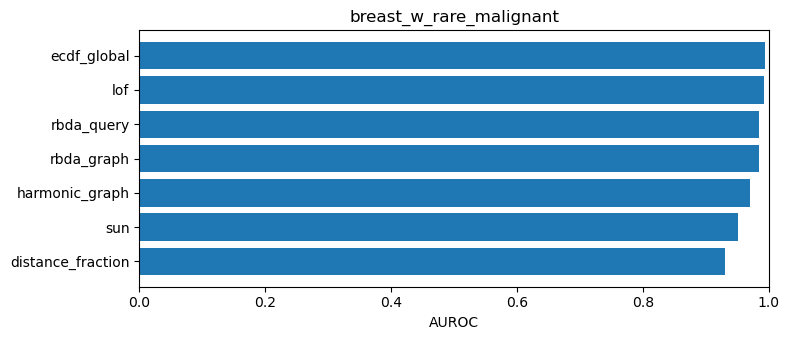

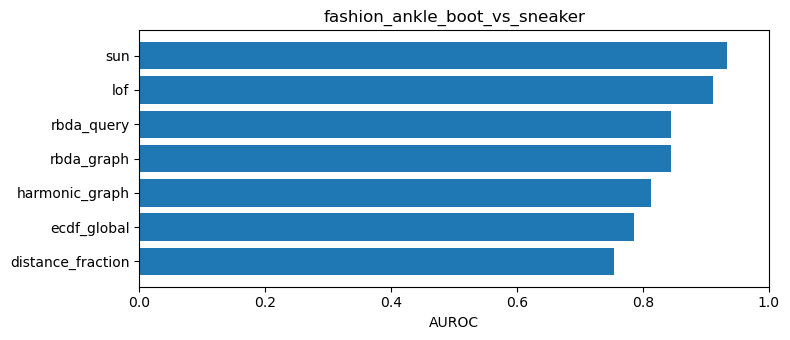

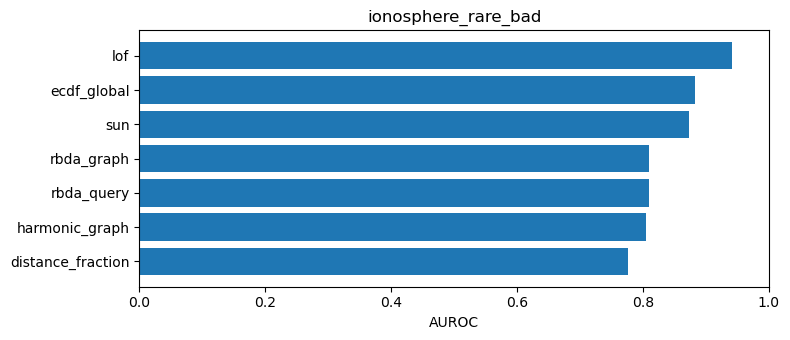

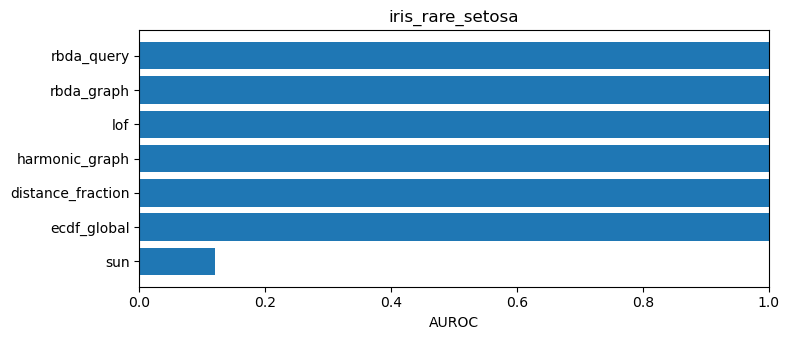

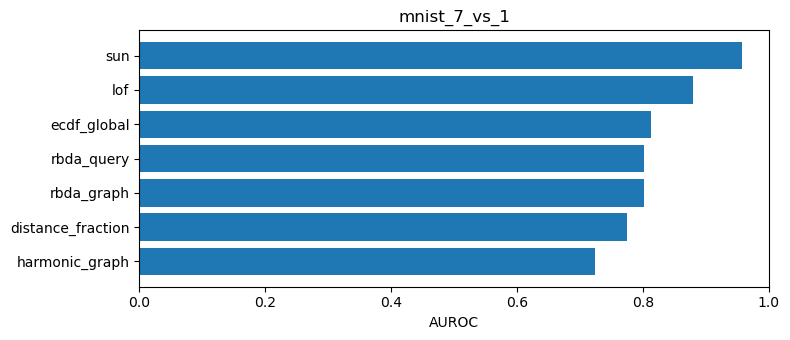

In [15]:
for dataset_name, subset in rankings.groupby("dataset", sort=False):
    ordered = subset.sort_values("dataset_rank", ascending=False)
    plt.figure(figsize=(8, 3.5))
    plt.barh(ordered["method"], ordered["auroc"])
    plt.xlim(0.0, 1.0)
    plt.xlabel("AUROC")
    plt.title(dataset_name)
    plt.tight_layout()
    plt.show()


## Easy extensions

To add another dataset:

```python
def prep_dataset_my_data(random_state=SEED):
    ...
    return OODDataset("my_data", X_fit, X_test, y_test)

DATASET_PREPARERS["my_data"] = prep_dataset_my_data
```

To add another method:

```python
METHOD_CONFIGS["my_method"] = {
    "estimator": MyEstimator,
    "params": {...},
    "score_sign": -1.0,  # use +1 when score_samples is already high-is-OOD
}
```

Other useful future datasets include CIFAR-10 vehicles versus animals, EMNIST digits versus letters, and a semantic OOD benchmark on frozen pretrained embeddings. Those are not enabled here because raw downloads and feature extraction would make this notebook less simple.